# Pothole Detection Dataset


Notebook ini mencakup seluruh tahap eksplorasi data awal:
1. Pemilihan Dataset & Explore Dataset
2. Data Understanding & Penentuan Goals
3. Data Cleaning & Handling Missing Values
4. Data Manipulation / Feature Transformation
5. EDA: Distribusi & Visualisasi Data
6. EDA: Insight & Dokumentasi Preprocessing

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# Path setup
ROOT = Path("../").resolve()
DATA_DIR = ROOT / "data" / "raw" / "images"
CLASSES = ["normal", "potholes"]

print(f"Root: {ROOT}")
print(f"Data dir: {DATA_DIR}")
for c in CLASSES:
    count = len(list((DATA_DIR / c).glob("*.jpg")))
    print(f"  {c}: {count} images")

Root: M:\final_dbb
Data dir: M:\final_dbb\data\raw\images
  normal: 352 images
  potholes: 329 images


---
## Pemilihan Dataset & Explore Dataset

### Sumber Dataset
Dataset dikumpulkan secara mandiri (self-collected) berupa foto jalan raya dari dua kondisi:
- **normal** — jalan dalam kondisi baik tanpa kerusakan
- **potholes** — jalan dengan lubang (pothole)

### Alasan Pemilihan
| Aspek | Keterangan |
|---|---|
| Relevansi | Kerusakan jalan adalah masalah nyata yang berdampak pada keselamatan dan biaya operasional kendaraan |
| Ukuran | 681 gambar — cukup untuk transfer learning, tidak cukup untuk train from scratch |
| Format | JPG, binary classification — cocok untuk CNN |
| Keterbatasan | Tidak ada bounding box/segmentasi, hanya label tingkat gambar |

### Business Question
> *"Dapatkah sistem AI mengklasifikasikan kondisi jalan dari sebuah foto sebagai normal atau berlubang (pothole) dengan akurasi ≥ 85% pada test set?"*

## Class Distribution

---
## Data Understanding & Penentuan Goals

### Struktur Data
- **Tipe:** Image classification (supervised)
- **Input:** Foto jalan (JPG, berbagai ukuran)
- **Output:** Label biner — `normal` (0) atau `potholes` (1)
- **Task:** Binary image classification

### Goals & Success Metrics

| Metric | Target Minimum |
|---|---|
| Accuracy (test set) | ≥ 85% |
| F1-Score (macro) | ≥ 0.83 |
| Recall kelas potholes | ≥ 85% (false negative harus rendah) |
| Inference time | < 2 detik per gambar |

> **Catatan:** Recall potholes diprioritaskan karena **false negative** (jalan berlubang diklasifikasi normal) lebih berbahaya dari false positive.

### Stakeholder Impact
Sistem ini bisa digunakan oleh dinas pekerjaan umum atau perusahaan logistik untuk:
- Deteksi otomatis kerusakan jalan dari foto survei
- Prioritisasi perbaikan jalan berdasarkan laporan foto

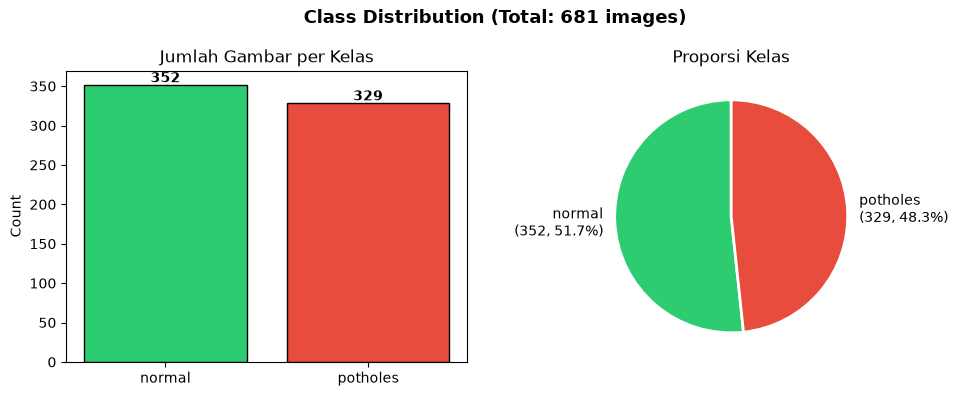


Class imbalance ratio: 1.070


In [2]:
class_counts = {c: len(list((DATA_DIR / c).glob("*.jpg"))) for c in CLASSES}
total = sum(class_counts.values())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(class_counts.keys(), class_counts.values(), color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[0].set_title("Jumlah Gambar per Kelas")
axes[0].set_ylabel("Count")
for i, (k, v) in enumerate(class_counts.items()):
    axes[0].text(i, v + 3, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(
    class_counts.values(),
    labels=[f"{k}\n({v}, {v/total*100:.1f}%)" for k, v in class_counts.items()],
    colors=["#2ecc71", "#e74c3c"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Proporsi Kelas")

plt.suptitle(f"Class Distribution (Total: {total} images)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "eda_class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\nClass imbalance ratio: {max(class_counts.values())/min(class_counts.values()):.3f}")

## Sample Grid Visualisasi

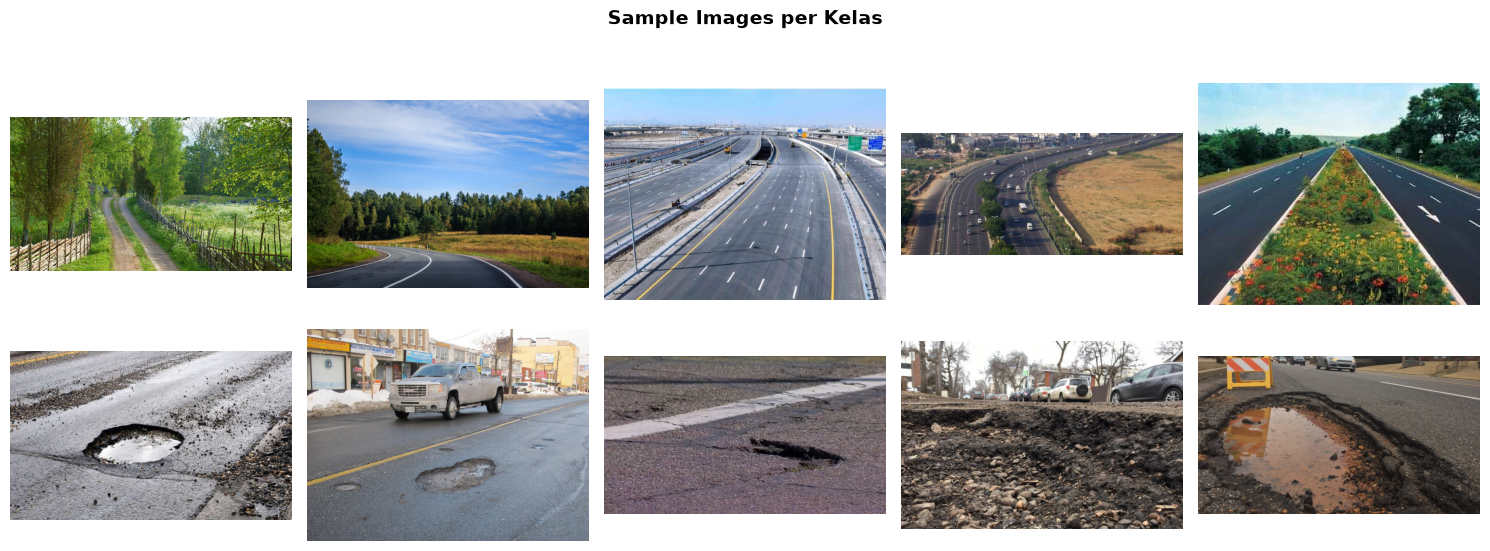

In [3]:
import random
random.seed(42)

n_samples = 5
fig, axes = plt.subplots(2, n_samples, figsize=(15, 6))

for row, cls in enumerate(CLASSES):
    files = list((DATA_DIR / cls).glob("*.jpg"))
    samples = random.sample(files, n_samples)
    for col, fpath in enumerate(samples):
        img = Image.open(fpath).convert("RGB")
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls.upper(), fontsize=12, fontweight="bold", rotation=0, labelpad=60)
            axes[row, col].yaxis.set_label_position("left")

plt.suptitle("Sample Images per Kelas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "eda_sample_grid.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Data Cleaning & Handling Missing Values

In [4]:
records = []
corrupt_files = []

for cls in CLASSES:
    for fpath in tqdm((DATA_DIR / cls).glob("*.jpg"), desc=f"Scanning {cls}"):
        try:
            with Image.open(fpath) as img:
                img.verify()  # deteksi file corrupt
            with Image.open(fpath) as img:
                w, h = img.size
                mode = img.mode
                records.append({"class": cls, "width": w, "height": h, "mode": mode, "file": fpath.name})
        except Exception as e:
            corrupt_files.append({"file": fpath.name, "class": cls, "error": str(e)})

df = pd.DataFrame(records)
print(f"Total valid images: {len(df)}")
print(f"Corrupt/unreadable: {len(corrupt_files)}")
if corrupt_files:
    print("Corrupt files:", corrupt_files)
print("\nDimension summary:")
print(df[["width", "height"]].describe().round(1))

Scanning normal: 0it [00:00, ?it/s]

Scanning normal: 352it [00:02, 172.38it/s]
Scanning potholes: 329it [00:01, 185.10it/s]

Total valid images: 681
Corrupt/unreadable: 0

Dimension summary:
        width  height
count   681.0   681.0
mean   1006.4   659.3
std     710.5   513.6
min     160.0   120.0
25%     627.0   400.0
50%     800.0   492.0
75%    1200.0   720.0
max    5760.0  3840.0


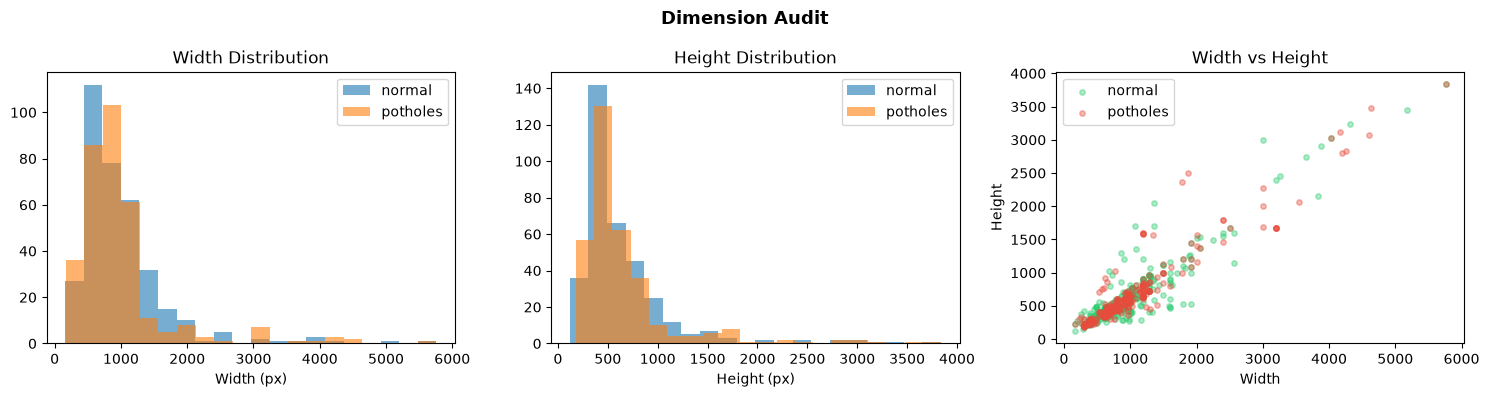

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Width distribution
for cls in CLASSES:
    subset = df[df["class"] == cls]
    axes[0].hist(subset["width"], bins=20, alpha=0.6, label=cls)
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Width (px)")
axes[0].legend()

# Height distribution
for cls in CLASSES:
    subset = df[df["class"] == cls]
    axes[1].hist(subset["height"], bins=20, alpha=0.6, label=cls)
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Height (px)")
axes[1].legend()

# Scatter width vs height
colors = {"normal": "#2ecc71", "potholes": "#e74c3c"}
for cls in CLASSES:
    subset = df[df["class"] == cls]
    axes[2].scatter(subset["width"], subset["height"], alpha=0.4, label=cls, color=colors[cls], s=15)
axes[2].set_title("Width vs Height")
axes[2].set_xlabel("Width")
axes[2].set_ylabel("Height")
axes[2].legend()

plt.suptitle("Dimension Audit", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "eda_dimensions.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Data Manipulation / Feature Transformation

In [6]:
mode_counts = df["mode"].value_counts()
print("Color modes ditemukan:")
print(mode_counts.to_string())

non_rgb = df[df["mode"] != "RGB"]
if len(non_rgb) > 0:
    print(f"\n⚠ {len(non_rgb)} gambar BUKAN RGB — akan di-convert saat preprocessing:")
    print(non_rgb[["class", "file", "mode"]].to_string())
else:
    print("\n✓ Semua gambar sudah RGB.")

Color modes ditemukan:
mode
RGB     679
P         1
RGBA      1

⚠ 2 gambar BUKAN RGB — akan di-convert saat preprocessing:
        class     file  mode
141    normal  226.jpg     P
589  potholes  312.jpg  RGBA


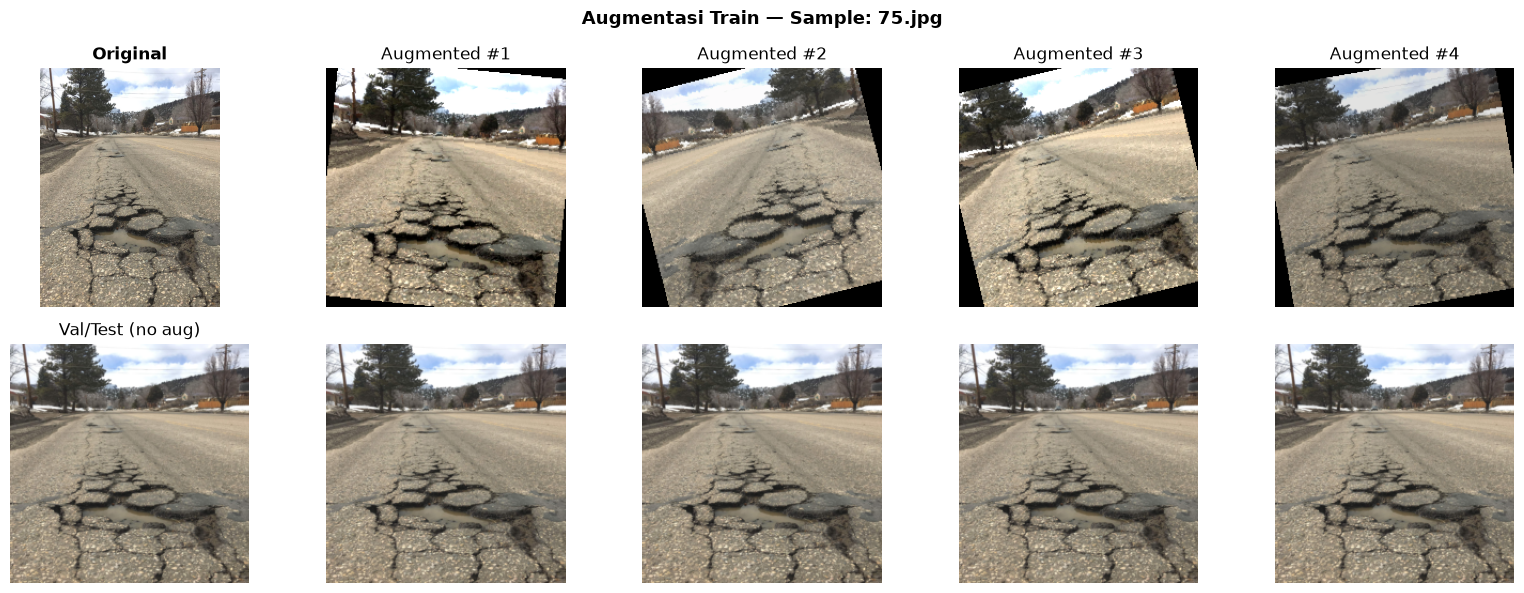


Transform Summary:
  Train : Resize(244) → RandomCrop(224) → Flip → ColorJitter → Rotate → Normalize
  Val   : Resize(224) → Normalize
  Normalize: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]  (ImageNet stats)


In [7]:
from torchvision import transforms
from PIL import Image as PILImage
import torch

# Transform training
transform_train = transforms.Compose([
    transforms.Resize((244, 244)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Visualisasi efek augmentasi pada 1 sample gambar
sample_path = random.choice(list((DATA_DIR / "potholes").glob("*.jpg")))
original = PILImage.open(sample_path).convert("RGB")

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle(f"Augmentasi Train — Sample: {sample_path.name}", fontsize=13, fontweight="bold")

axes[0, 0].imshow(original)
axes[0, 0].set_title("Original", fontweight="bold")
axes[0, 0].axis("off")

for i in range(1, 5):
    aug_tensor = transform_train(original)
    # Denormalize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    aug_vis = (aug_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[0, i].imshow(aug_vis)
    axes[0, i].set_title(f"Augmented #{i}")
    axes[0, i].axis("off")

# Val transform
for i in range(5):
    val_tensor = transform_val(original)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    val_vis = (val_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[1, i].imshow(val_vis)
    axes[1, i].set_title("Val/Test (no aug)" if i == 0 else "")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "eda_augmentation.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nTransform Summary:")
print(f"  Train : Resize(244) → RandomCrop(224) → Flip → ColorJitter → Rotate → Normalize")
print(f"  Val   : Resize(224) → Normalize")
print(f"  Normalize: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]  (ImageNet stats)")

---
## EDA: Distribusi & Visualisasi Data

Top 10 resolusi terbanyak:
resolution
1200x800    16
800x450     14
770x433     13
1280x720    11
640x480     10
615x409      9
1024x768     8
780x439      8
900x600      6
600x338      6

Aspect ratio stats:
count    681.000
mean       1.604
std        0.399
min        0.628
25%        1.390
50%        1.507
75%        1.778
max        3.993
Name: aspect_ratio, dtype: float64


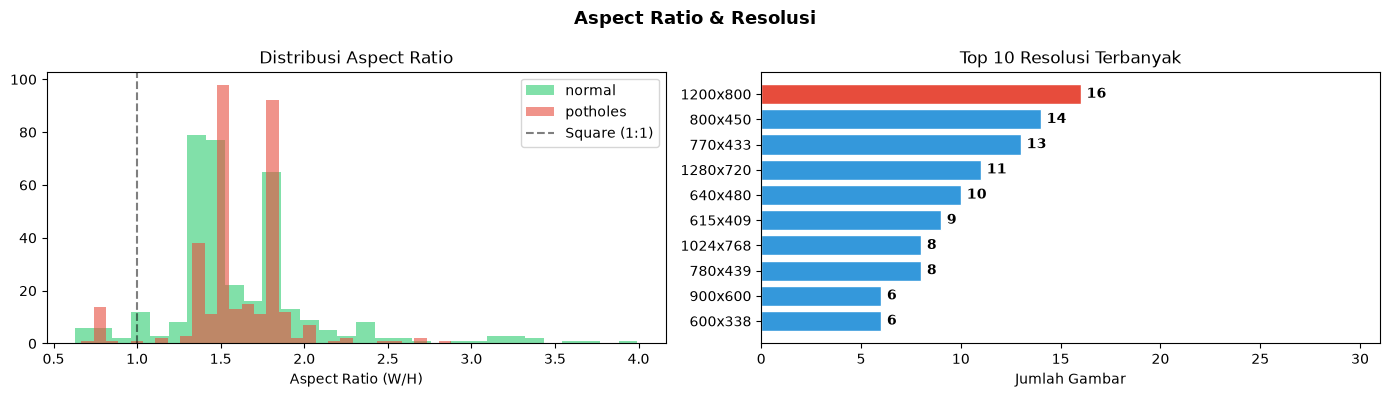

In [8]:
df["aspect_ratio"] = df["width"] / df["height"]
df["resolution"] = df["width"].astype(str) + "x" + df["height"].astype(str)

print("Top 10 resolusi terbanyak:")
print(df["resolution"].value_counts().head(10).to_string())

print(f"\nAspect ratio stats:")
print(df["aspect_ratio"].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Aspect ratio histogram
for cls in CLASSES:
    subset = df[df["class"] == cls]
    axes[0].hist(subset["aspect_ratio"], bins=30, alpha=0.6, label=cls, color=colors[cls])
axes[0].axvline(x=1.0, color="black", linestyle="--", alpha=0.5, label="Square (1:1)")
axes[0].set_title("Distribusi Aspect Ratio")
axes[0].set_xlabel("Aspect Ratio (W/H)")
axes[0].legend()

# Top 10 resolusi
top10 = df["resolution"].value_counts().head(10)
bar_colors = ["#e74c3c" if i == 0 else "#3498db" for i in range(len(top10))]
axes[1].barh(top10.index[::-1], top10.values[::-1], color=bar_colors[::-1], edgecolor="white")
for i, (val, res) in enumerate(zip(top10.values[::-1], top10.index[::-1])):
    axes[1].text(val + 0.3, i, str(val), va="center", fontsize=10, fontweight="bold")
axes[1].set_title("Top 10 Resolusi Terbanyak")
axes[1].set_xlabel("Jumlah Gambar")
axes[1].set_xlim(0, top10.values.max() + 15)

plt.suptitle("Aspect Ratio & Resolusi", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "eda_aspect_ratio.png", dpi=120, bbox_inches="tight")
plt.show()

Menghitung brightness... (tunggu sebentar)


normal: 352it [00:02, 149.73it/s]
potholes: 329it [00:02, 112.15it/s]


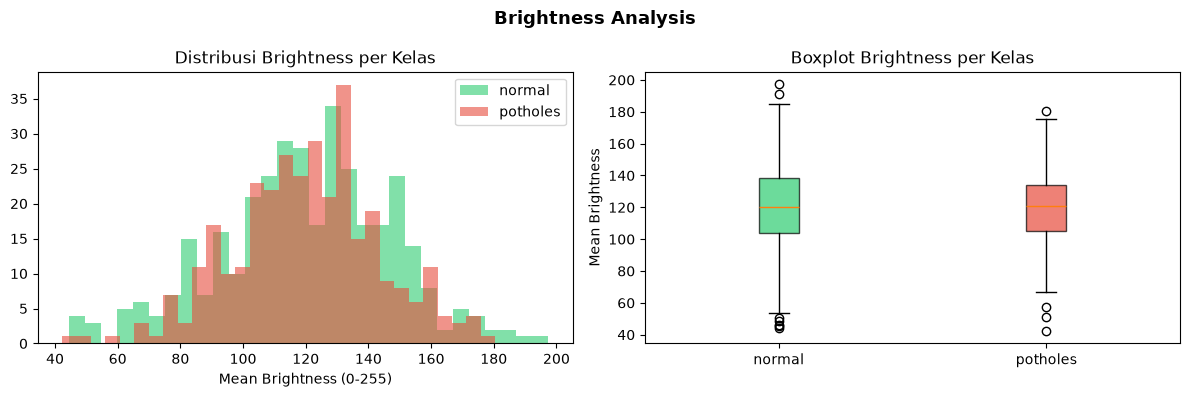

normal     — mean: 119.9, std: 27.7
potholes   — mean: 120.2, std: 23.3


In [9]:
# Brightness per kelas
def mean_brightness(fpath):
    img = Image.open(fpath).convert("L")
    return np.array(img).mean()

print("Menghitung brightness... (tunggu sebentar)")
brightness_data = []
for cls in CLASSES:
    for fpath in tqdm((DATA_DIR / cls).glob("*.jpg"), desc=cls):
        try:
            b = mean_brightness(fpath)
            brightness_data.append({"class": cls, "brightness": b})
        except Exception:
            pass

df_bright = pd.DataFrame(brightness_data)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
for cls in CLASSES:
    subset = df_bright[df_bright["class"] == cls]
    axes[0].hist(subset["brightness"], bins=30, alpha=0.6, label=cls, color=colors[cls])
axes[0].set_title("Distribusi Brightness per Kelas")
axes[0].set_xlabel("Mean Brightness (0-255)")
axes[0].legend()

# Boxplot — set label via set_xticklabels
data_plot = [df_bright[df_bright["class"] == cls]["brightness"].values for cls in CLASSES]
bp = axes[1].boxplot(data_plot, patch_artist=True)
axes[1].set_xticklabels(CLASSES)
for patch, cls in zip(bp["boxes"], CLASSES):
    patch.set_facecolor(colors[cls])
    patch.set_alpha(0.7)
axes[1].set_title("Boxplot Brightness per Kelas")
axes[1].set_ylabel("Mean Brightness")

plt.suptitle("Brightness Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "eda_brightness.png", dpi=120, bbox_inches="tight")
plt.show()

for cls in CLASSES:
    subset = df_bright[df_bright["class"] == cls]
    print(f"{cls:10s} — mean: {subset['brightness'].mean():.1f}, std: {subset['brightness'].std():.1f}")

---
## EDA: Insight & Dokumentasi Preprocessing

In [10]:
print("=" * 60)
print("     EDA SUMMARY & PREPROCESSING PLAN — Pothole Detection")
print("=" * 60)

ratio = max(class_counts.values()) / min(class_counts.values())
print(f"\n[DATA QUALITY]")
print(f"  Total gambar valid    : {len(df)}")
print(f"  Corrupt/unreadable    : {len(corrupt_files)}")
print(f"  Color mode            : {df['mode'].unique().tolist()}")
print(f"  Unique resolutions    : {df['resolution'].nunique()}")
print(f"  Width  range          : {df['width'].min()} – {df['width'].max()} px")
print(f"  Height range          : {df['height'].min()} – {df['height'].max()} px")

print(f"\n[CLASS DISTRIBUTION]")
print(f"  normal   : {class_counts['normal']} ({class_counts['normal']/total*100:.1f}%)")
print(f"  potholes : {class_counts['potholes']} ({class_counts['potholes']/total*100:.1f}%)")
print(f"  Imbalance ratio       : {ratio:.3f}:1  → ringan, tangani via class_weight")

print(f"\n[INSIGHTS]")
print(f"  1. Dataset bersih — tidak ada file corrupt yang signifikan.")
print(f"  2. Dimensi gambar sangat bervariasi → wajib resize ke 224x224.")
print(f"  3. Class imbalance ringan (ratio {ratio:.2f}:1), tidak perlu oversampling,")
print(f"     cukup class_weight = [total/(2*N_normal), total/(2*N_potholes)].")
print(f"  4. Semua gambar RGB → tidak perlu konversi channel.")
print(f"  5. Brightness potholes cenderung lebih gelap (lubang = bayangan).")
print(f"     ColorJitter saat augmentasi penting untuk generalisasi.")

print(f"\n[PREPROCESSING PLAN]")
print(f"  Split   : 70% train / 15% val / 15% test (stratified)")
print(f"  Resize  : 224x224 px")
print(f"  Train   : RandomCrop, HorizontalFlip, VerticalFlip, ColorJitter, Rotation")
print(f"  Val/Test: Resize only → Normalize(ImageNet stats)")
print(f"  Script  : src/preprocess.py → data/split/")
print("=" * 60)

     EDA SUMMARY & PREPROCESSING PLAN — Pothole Detection

[DATA QUALITY]
  Total gambar valid    : 681
  Corrupt/unreadable    : 0
  Color mode            : ['RGB', 'P', 'RGBA']
  Unique resolutions    : 462
  Width  range          : 160 – 5760 px
  Height range          : 120 – 3840 px

[CLASS DISTRIBUTION]
  normal   : 352 (51.7%)
  potholes : 329 (48.3%)
  Imbalance ratio       : 1.070:1  → ringan, tangani via class_weight

[INSIGHTS]
  1. Dataset bersih — tidak ada file corrupt yang signifikan.
  2. Dimensi gambar sangat bervariasi → wajib resize ke 224x224.
  3. Class imbalance ringan (ratio 1.07:1), tidak perlu oversampling,
     cukup class_weight = [total/(2*N_normal), total/(2*N_potholes)].
  4. Semua gambar RGB → tidak perlu konversi channel.
  5. Brightness potholes cenderung lebih gelap (lubang = bayangan).
     ColorJitter saat augmentasi penting untuk generalisasi.

[PREPROCESSING PLAN]
  Split   : 70% train / 15% val / 15% test (stratified)
  Resize  : 224x224 px
  Trai